By the help of Grad-CAM and Integrated Gradients, investigate which area of an adversarial example of an image makes your favorite neural network confused.

Compare most important area of an adversarial example with the important area of the original image.

Investigate what will happen if you consider softmax layer for Grad-CAM and the previous-layer of the softmax layer for IG for estimating gradients.

In [161]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions


## Load Model and Preprocess Image

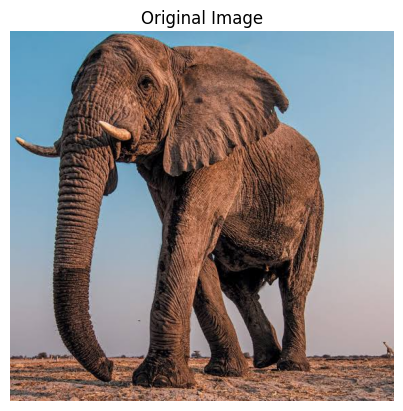

In [162]:
# Load model with pretrained ImageNet weights
model = MobileNetV2(weights='imagenet')
model.trainable = False

img_path = keras.utils.get_file(
    "elephant.jpg", "https://i.ibb.co/SXMs7yM7/elephant.jpg"
)

original_img = image.load_img(img_path)
plt.imshow(original_img) ;
plt.title('Original Image')
plt.axis('off')
plt.show()

# Load and preprocess
def load_img_tensor(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    original_img = img.copy()
    x = image.img_to_array(img)
    x = preprocess_input(x)
    x = np.expand_dims(x, axis=0)
    return tf.convert_to_tensor(x), original_img

img_tensor, original_img = load_img_tensor(img_path)


## Adversarial (FGSM)

In [163]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    prediction = model(img_tensor)
    class_idx = tf.argmax(prediction[0])
    loss = loss_object(tf.one_hot([class_idx], 1000), prediction)

# FGSM
gradient = tape.gradient(loss, img_tensor)
adv_img_tensor = img_tensor + 0.01 * tf.sign(gradient)
adv_img_tensor = tf.clip_by_value(adv_img_tensor, -1.0, 1.0)


## Grad-CAM Function

In [164]:
import cv2

def get_gradcam_heatmap(img_tensor, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap + 1e-8)
    return heatmap.numpy()


## Grad-CAM Heatmaps

In [165]:
last_conv_layer_name = 'Conv_1'

# Grad-CAM heatmaps
heatmap_orig = get_gradcam_heatmap(img_tensor, model, last_conv_layer_name)
heatmap_adv = get_gradcam_heatmap(adv_img_tensor, model, last_conv_layer_name)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1413']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


## Generate HeatMap function

In [166]:
def superimpose_heatmap(heatmap, img):
    heatmap = cv2.resize(heatmap, (img.width, img.height))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return heatmap

original_img_np = np.array(original_img)

# Superimpose heatmaps
heatmap_orig_img = superimpose_heatmap(heatmap_orig, original_img)
heatmap_adv_img = superimpose_heatmap(heatmap_adv, original_img)


## Overlay Heatmaps on Image

In [167]:
def superimpose_heatmap(heatmap, original_img, alpha=0.4):

    if tf.is_tensor(heatmap):
        heatmap = heatmap.numpy()

    heatmap = cv2.resize(heatmap, (original_img.size[0], original_img.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    original_np = np.array(original_img)
    superimposed_img = cv2.addWeighted(original_np, 1 - alpha, heatmap_color, alpha, 0)
    return superimposed_img

## Display the image, HeatMap and Overlay with Grad CAM

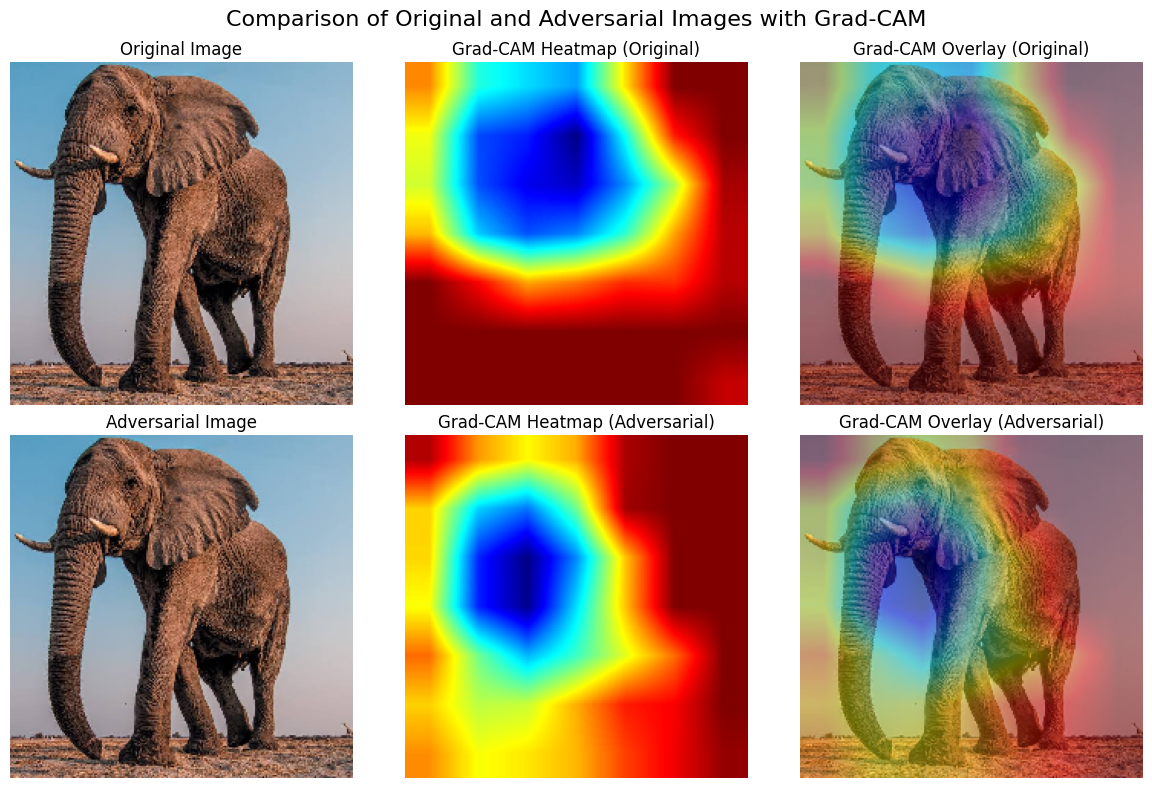

In [168]:
plt.figure(figsize=(12, 8))


plt.subplot(2, 3, 1)
plt.imshow(original_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(heatmap_orig_img)
plt.title('Grad-CAM Heatmap (Original)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(superimpose_heatmap(heatmap_orig, original_img))
plt.title('Grad-CAM Overlay (Original)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(original_img)
plt.title('Adversarial Image')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(heatmap_adv_img)
plt.title('Grad-CAM Heatmap (Adversarial)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(superimpose_heatmap(heatmap_adv, original_img))
plt.title('Grad-CAM Overlay (Adversarial)')
plt.axis('off')

plt.suptitle('Comparison of Original and Adversarial Images with Grad-CAM', fontsize=16)
plt.tight_layout()
plt.show()


# Integrated Gradients (IG)

### Integrated Gradients Functions

In [169]:

def interpolate_images(baseline, image, alphas):
    alphas_x = alphas[:, tf.newaxis, tf.newaxis, tf.newaxis]
    delta = image - baseline
    return baseline + alphas_x * delta

def compute_integrated_gradients(image, model, target_class_idx, m_steps=50):
    baseline = tf.zeros(shape=image.shape)
    alphas = tf.linspace(0.0, 1.0, m_steps + 1)
    interpolated_images = interpolate_images(baseline, image, alphas)

    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        predictions = model(interpolated_images)
        outputs = predictions[:, target_class_idx]

    grads = tape.gradient(outputs, interpolated_images)
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_grads = (image - baseline) * avg_grads
    return tf.reduce_sum(tf.math.abs(integrated_grads), axis=-1)[0]


## Run IG on Original and Adversarial Images

In [170]:
# Get target class index
target_class = tf.argmax(model(img_tensor)[0])

# Compute attributions
ig_orig = compute_integrated_gradients(img_tensor, model, target_class)
ig_adv = compute_integrated_gradients(adv_img_tensor, model, target_class)


## Visualize IG Heatmaps

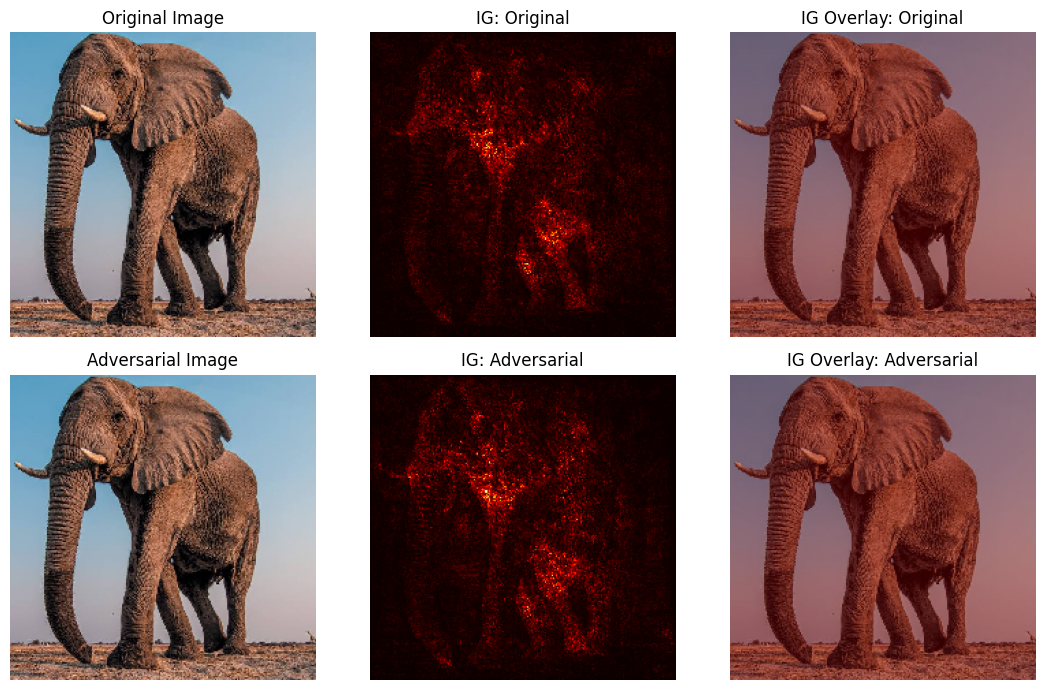

In [171]:
plt.figure(figsize=(11, 7))

plt.subplot(2, 3, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(ig_orig.numpy(), cmap='hot')
plt.title("IG: Original")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(superimpose_heatmap(ig_orig, original_img), cmap='hot')
plt.title("IG Overlay: Original")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(original_img)
plt.title("Adversarial Image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(ig_adv.numpy(), cmap='hot')
plt.title("IG: Adversarial")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(superimpose_heatmap(ig_adv, original_img), cmap='hot')
plt.title("IG Overlay: Adversarial")
plt.axis("off")


plt.tight_layout()
plt.show()


## Effect of Using Softmax Layer


In [172]:
softmax_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
# Use softmax model (not recommended for IG)
ig_orig_softmax = compute_integrated_gradients(img_tensor, softmax_model, target_class)
ig_adv_softmax = compute_integrated_gradients(adv_img_tensor, softmax_model, target_class)


## Grad-CAM with Softmax and IG with Layer Before Softmax

In [173]:
# Find the layer before the softmax
layer_before_softmax = model.layers[-2].name
print(f"Layer before softmax: {layer_before_softmax}")

def get_gradcam_heatmap_softmax_gradient(img_tensor, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        softmax_predictions = tf.nn.softmax(predictions)
        if pred_index is None:
            pred_index = tf.argmax(softmax_predictions[0])
        class_channel = softmax_predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap + 1e-8)
    return heatmap.numpy()


heatmap_orig_softmax_grad = get_gradcam_heatmap_softmax_gradient(img_tensor, model, last_conv_layer_name)
heatmap_adv_softmax_grad = get_gradcam_heatmap_softmax_gradient(adv_img_tensor, model, last_conv_layer_name)


def compute_integrated_gradients_intermediate_layer(image, model, target_layer_name, target_class_idx, m_steps=50):
    baseline = tf.zeros(shape=image.shape)
    alphas = tf.linspace(0.0, 1.0, m_steps + 1)
    interpolated_images = interpolate_images(baseline, image, alphas)

    intermediate_layer_model = tf.keras.models.Model(inputs=model.input, outputs=model.get_layer(target_layer_name).output)

    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        intermediate_outputs = intermediate_layer_model(interpolated_images)
        predictions = model(interpolated_images)
        outputs = predictions[:, target_class_idx]

    grads = tape.gradient(outputs, intermediate_outputs)

    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        predictions = model(interpolated_images)
        outputs = predictions[:, target_class_idx]

    grads = tape.gradient(outputs, interpolated_images)
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_grads = (image - baseline) * avg_grads
    return tf.reduce_sum(tf.math.abs(integrated_grads), axis=-1)[0]


ig_orig_standard = compute_integrated_gradients(img_tensor, model, target_class)
ig_adv_standard = compute_integrated_gradients(adv_img_tensor, model, target_class)

Layer before softmax: global_average_pooling2d_9


## Visualize the results

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

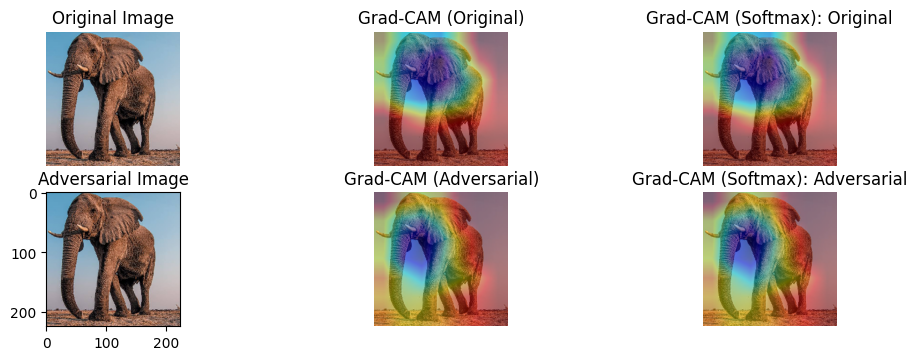

In [174]:

plt.figure(figsize=(12, 8))

plt.subplot(431)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(4, 3, 2)
plt.imshow(superimpose_heatmap(heatmap_orig, original_img))
plt.title('Grad-CAM (Original)')
plt.axis('off')

plt.subplot(433)
plt.imshow(superimpose_heatmap(heatmap_orig_softmax_grad, original_img), cmap='jet')
plt.title("Grad-CAM (Softmax): Original")
plt.axis("off")

plt.subplot(434)
plt.imshow(original_img)
plt.title("Adversarial Image")
# plt.axis("off")

plt.subplot(435)
plt.imshow(superimpose_heatmap(heatmap_adv, original_img))
plt.title('Grad-CAM (Adversarial)')
plt.axis('off')

plt.subplot(436)
plt.imshow(superimpose_heatmap(heatmap_adv_softmax_grad, original_img), cmap='jet')
plt.title("Grad-CAM (Softmax): Adversarial")
plt.axis("off")



# plt.subplot(235)
# plt.imshow(superimpose_heatmap(heatmap_adv_softmax_grad, original_img), cmap='jet')
# plt.title("Grad-CAM Overlay (Softmax Grad): Adversarial")
# plt.axis("off")

# plt.subplot(233)
# plt.imshow(superimpose_heatmap(ig_orig_standard, original_img), cmap='jet')
# plt.title("Standard IG Overlay: Original")
# plt.axis("off")

# plt.subplot(236)
# plt.imshow(superimpose_heatmap(ig_adv_standard, original_img), cmap='jet')
# plt.title("Standard IG Overlay: Adversarial")
# plt.axis("off")


# plt.tight_layout()
# plt.suptitle("Investigating Softmax Gradient for Grad-CAM and Standard IG", fontsize=16, y=1.02)
# plt.show()


# plt.subplot(2, 3, 1)
# plt.imshow(original_img)
# plt.title('Original Image')
# plt.axis('off')

# plt.subplot(2, 3, 2)
# plt.imshow(heatmap_orig_img)
# plt.title('Grad-CAM Heatmap (Original)')
# plt.axis('off')



# plt.subplot(2, 3, 4)
# plt.imshow(original_img)
# plt.title('Adversarial Image')
# plt.axis('off')

# plt.subplot(2, 3, 5)
# plt.imshow(heatmap_adv_img)
# plt.title('Grad-CAM Heatmap (Adversarial)')
# plt.axis('off')

# plt.subplot(2, 3, 6)
# plt.imshow(superimpose_heatmap(heatmap_adv, original_img))
# plt.title('Grad-CAM Overlay (Adversarial)')
# plt.axis('off')
